**Initialization & Importing Libraries**

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

#Style
sns.set_theme(style = "whitegrid")
plt.rcParams["figure.dpi"] = 100

#Load Dataset
df = pd.read_csv("adult.csv")

#Clean NULL and Unknown Values
df.replace('?', pd.NA, inplace = True)
df.dropna(inplace = True)

df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
5,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K
6,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,<=50K


**TASK 1**

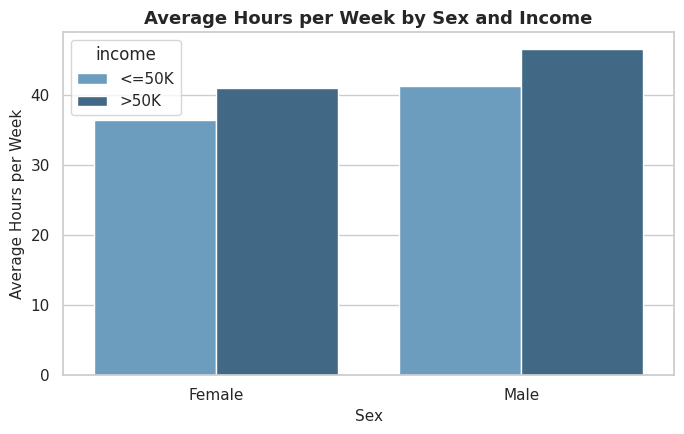

In [12]:
plt.figure(figsize=(7, 4.5))
sns.barplot(
    data=df,
    x="sex",
    y="hours.per.week",
    hue="income",
    estimator="mean",
    errorbar=None,
    palette="Blues_d",
)

plt.title("Average Hours per Week by Sex and Income", fontsize=13, fontweight="bold")
plt.xlabel("Sex", fontsize=11)
plt.ylabel("Average Hours per Week", fontsize=11)
plt.tight_layout()
plt.show()

**TASK 2**

/tmp/ipykernel_7615/1913861775.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


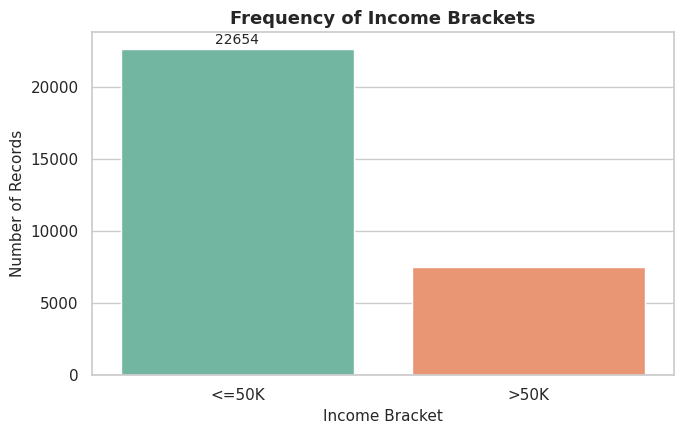

Most Common Category: <=50K


<Figure size 640x480 with 0 Axes>

Most Common Category: <=50K


In [16]:
#Count Plot
plt.figure(figsize=(7, 4.5))
ax = sns.countplot(
    data = df,
    x = "income",
    palette = "Set2"
)

plt.title("Frequency of Income Brackets", fontsize = 13, fontweight = "bold")
plt.xlabel("Income Bracket", fontsize = 11)
plt.ylabel("Number of Records", fontsize = 11)

#Annotations
for p in ax.patches:
  ax.annotate(
      f"{int(p.get_height())}",
      (p.get_x() + p.get_width() / 2.0, p.get_height() + 100),
      ha = "center",
      va = "bottom",
      fontsize = 10,
  )

  plt.tight_layout()
  plt.show()

  #Answer
  print(f"Most Common Category: {df['income'].mode()[0]}")

**TASK 3**

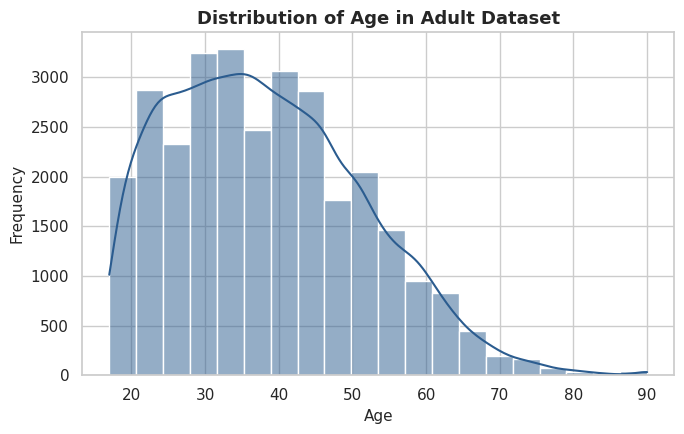

In [17]:
# Task 3: Histogram
plt.figure(figsize=(7, 4.5))
sns.histplot(df["age"], kde=True, bins=20, color="#2b5c8f")

plt.title("Distribution of Age in Adult Dataset", fontsize=13, fontweight="bold")
plt.xlabel("Age", fontsize=11)
plt.ylabel("Frequency", fontsize=11)
plt.tight_layout()
plt.show()

# Description:
# The distribution is right-skewed (positively skewed),
# indicating that the majority of people in the dataset are younger working adults.

**TASK 4**

/tmp/ipykernel_7615/1266151469.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


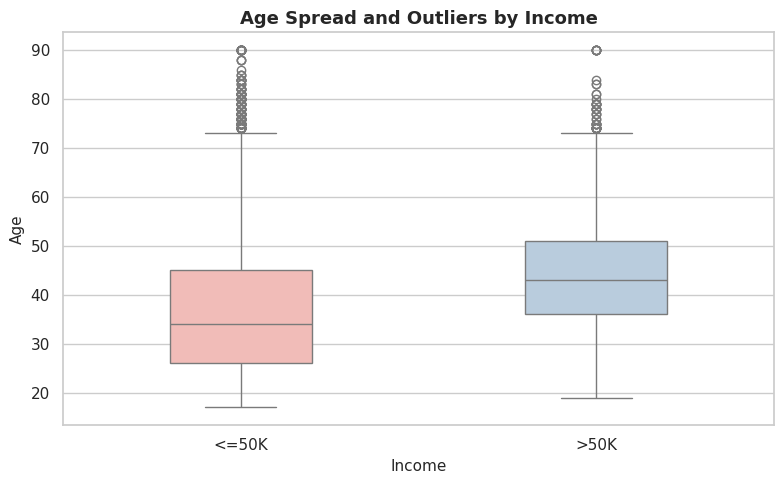

In [18]:
# Task 4: Box Plot
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df, x="income", y="age", palette="Pastel1", width=0.4
)

plt.title("Age Spread and Outliers by Income", fontsize=13, fontweight="bold")
plt.xlabel("Income", fontsize=11)
plt.ylabel("Age", fontsize=11)
plt.tight_layout()
plt.show()

# Visual Observation:
# There are noticeable black diamond points extending beyond the upper whiskers
# for both income brackets, which indicates visual outliers representing older individuals.

**TASK 5**

In [19]:
# Task 5: IQR Outlier Calculation (Age)
col = "age"
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
print(f"Lower Bound: {lower_bound:.2f} | Upper Bound: {upper_bound:.2f}")
print(f"Outliers detected by IQR: {len(outliers_iqr)}")

# Comparison:
# The mathematical IQR count matches the dots observed beyond the whiskers in the boxplot.

Q1: 28.00, Q3: 47.00, IQR: 19.00
Lower Bound: -0.50 | Upper Bound: 75.50
Outliers detected by IQR: 169


**TASK 6**

In [22]:
# Task 6: Z-score Method
df["zscore"] = stats.zscore(df["age"])
outliers_z = df[df["zscore"].abs() > 3]

print(f"Outliers detected by Z-score (|z| > 3): {len(outliers_z)}")

# Comparison Explanation:
# IQR and Z-score often flag a different number of outliers when the data is right-skewed (like age).
# The IQR method is robust to skewness and flags points strictly based on quartile distance.
# Z-score assumes a symmetrical, normal distribution; the long tail of older ages pulls the mean and standard
# deviation upward, making the Z-score's "normal range" wider and missing outliers that IQR flags.

Outliers detected by Z-score (|z| > 3): 120


**TASK 7**

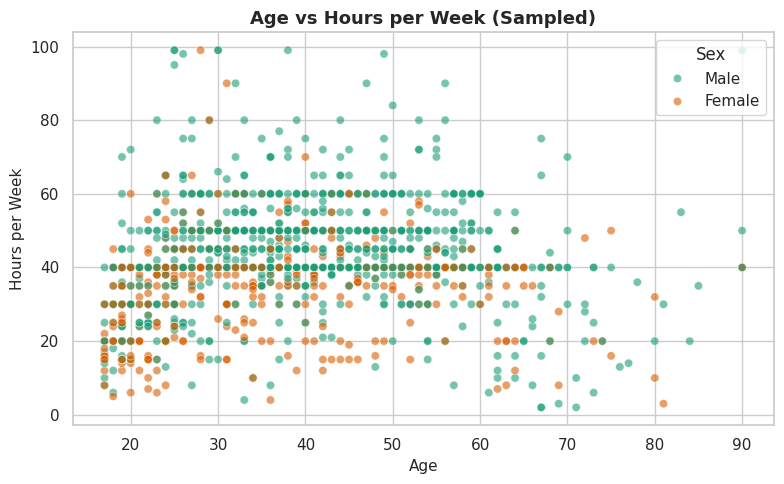

In [24]:
# Task 7: Scatter Plot
# Plotting a subset (e.g., 2000 points) so the plot remains neat and readable
subset = df.sample(n=2000, random_state=42)

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=subset,
    x="age",
    y="hours.per.week",
    hue="sex",
    alpha=0.6,
    palette="Dark2",
)

plt.title("Age vs Hours per Week (Sampled)", fontsize=13, fontweight="bold")
plt.xlabel("Age", fontsize=11)
plt.ylabel("Hours per Week", fontsize=11)
plt.legend(title="Sex", frameon=True)
plt.tight_layout()
plt.show()

# Observation:
# There is no strong linear relationship. Most data points form dense clusters around standard
# full-time working hours (e.g., 40 hours/week) across nearly all working ages.

**TASK 8**

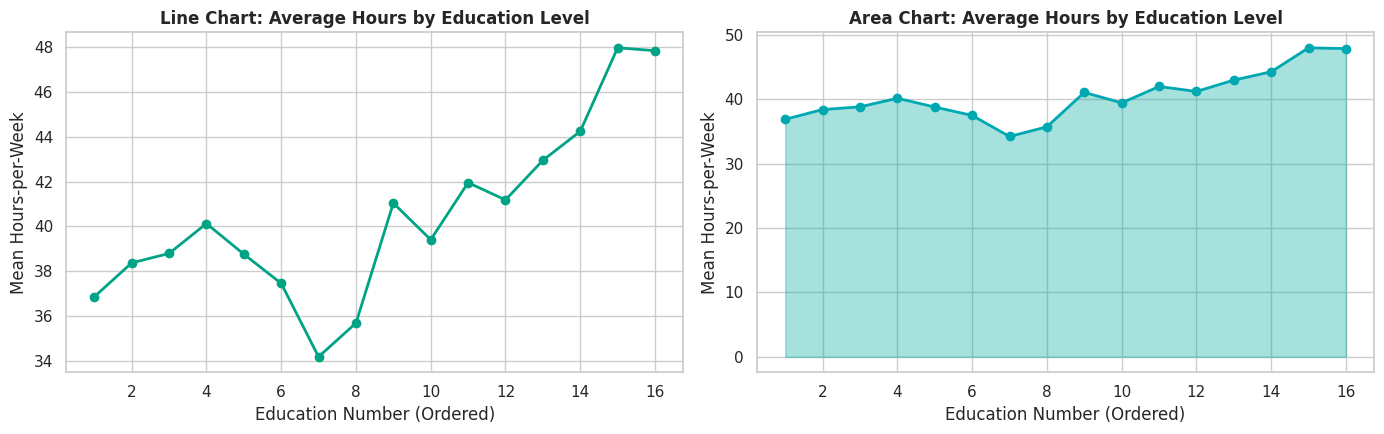

In [31]:
# Task 8: Ordered Variable Grouping & Trend
# Using 'education-num' as it is logically ordered from least (1) to most (16) education
trend_df = (
    df.groupby('education.num', observed=False)['hours.per.week'].mean().reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# 1. Line Chart
axes[0].plot(
    trend_df['education.num'],
    trend_df['hours.per.week'],
    marker='o',
    color='#00A385',
    linewidth=2,
)
axes[0].set_title(
    'Line Chart: Average Hours by Education Level', fontweight='bold'
)
axes[0].set_xlabel('Education Number (Ordered)')
axes[0].set_ylabel('Mean Hours-per-Week')

# 2. Area Chart
axes[1].fill_between(
    trend_df['education.num'], trend_df['hours.per.week'], color='#00A9A1', alpha=0.35
)
axes[1].plot(
    trend_df['education.num'],
    trend_df['hours.per.week'],
    color='#00A9B2',
    marker='o',
    linewidth=2,
)
axes[1].set_title(
    'Area Chart: Average Hours by Education Level', fontweight='bold'
)
axes[1].set_xlabel('Education Number (Ordered)')
axes[1].set_ylabel('Mean Hours-per-Week')

plt.tight_layout()
plt.show()

# Comparison:
# The line chart is clear and effective for spotting the slight upward trend in working hours as education increases.
# The area chart draws visual weight downward, heavily emphasizing the baseline volume of hours worked (around 35-45)
# rather than just the trend of change.

**TASK 9**

/tmp/ipykernel_7615/1663192861.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=income_counts.index, y=income_counts.values, ax=axes[0], palette="Greens_d")
/tmp/ipykernel_7615/1663192861.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=income_counts.index, y=income_counts.values, ax=axes[1], palette="Reds_d")


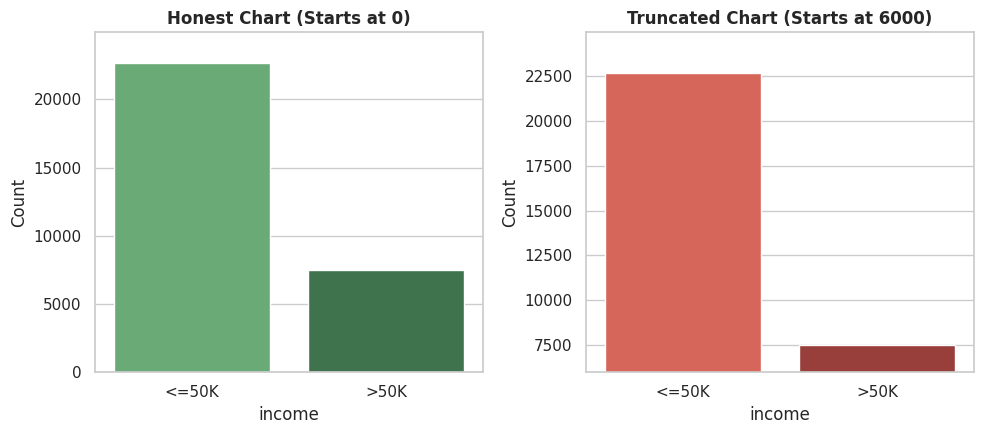

In [32]:
# Get counts for the categorical variable (income)
income_counts = df['income'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

# Honest Chart (Starts at 0)
sns.barplot(x=income_counts.index, y=income_counts.values, ax=axes[0], palette="Greens_d")
axes[0].set_ylim(0, max(income_counts) * 1.1)
axes[0].set_title("Honest Chart (Starts at 0)", fontweight="bold")
axes[0].set_ylabel("Count")

# Truncated Chart (Starts at 6000)
sns.barplot(x=income_counts.index, y=income_counts.values, ax=axes[1], palette="Reds_d")
axes[1].set_ylim(6000, max(income_counts) * 1.1)
axes[1].set_title("Truncated Chart (Starts at 6000)", fontweight="bold")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()